In [2]:
import cvxpy as cp
import numpy as np
from matplotlib import pyplot as plt

## Problem 1 (Stochastic dynamic programming)

In this problem we will explore discrete-time dynamic programming for stochastic systems; that is, systems where the result of taking a certain action is not deterministic, but instead any of a set of results may occur, according to some known probability distribution. In this case, we cannot optimize the value function directly, since even choosing a known sequence of actions will not always give in the same result. Instead, we optimize the [_expected value_](https://en.wikipedia.org/wiki/Expected_value) of the value function instead (if it's been a while since you've taken a probability class, or if you've never taken one, that Wikipedia article may be helpful).

### (a) Small hand-calculation problem
Suppose we have a machine that is either running or is broken down. If it runs throughout one
week, it makes a gross profit of \\$100. If it fails during the week, gross profit is zero. If it is running at the start of the week and we perform preventive maintenance, the probability that it will fail during the week is 0.4. If we do not perform such maintenance, the probability of failure is 0.7. However, maintenance will cost \\$20. If the machine is broken down at the start of the week, it may either be repaired at a cost of \\$40, in which case it will fail during the week with a probability
of 0.4, or it may be replaced at a cost of \$150 by a new machine; a new machine is guaranteed to run through its first week of operation. Using dynamic programming, find the optimal repair, replacement, and maintenance policy that maximizes total expected profit over four weeks, assuming a new machine at the start of the first week.

[Show work here...]

### (b) Larger system to solve by code

Now we consider a more complicated system and a longer time horizon.

Consider the same scenario as above, but with two additional machine states: overspeeding and destroyed. In the overspeeding state, the machine will with probability 0.5 produce \\$120 at the end of the week, but will otherwise be destroyed and produce no revenue for that week. If the machine is in the "destroyed" state at the start of a week, it may be replaced with a new machine for \\$150, the same as if it were broken down; otherwise it will produce no revenue for that week and remain in the destroyed state. A destroyed machine may not be repaired.

Here are the state transitions possible in this new system:

- If the machine is in the "running" state at the start of the week:
    - If you do nothing (cost: \\$0)
        - With probability 0.3 it will produce \\$100 and remain in the "running" state at the end of the week.
        - With probabiity 0.63 it will produce \\$0 and enter the "broken down" state at the end of the week.
        - With probability 0.07 it will produce \\$100 and enter the "overspeeding" state at the end of the week.
    - If you maintain the machine (cost: \\$20):
        - With probability 0.6 it will produce \\$100 and remain in the "running" state at the end of the week.
        - With probabiity 0.37 it will produce \\$0 and enter the "broken down" state at the end of the week.
        - With probability 0.03 it will produce \\$100 and enter the "overspeeding" state at the end of the week.
- If the machine is in the "broken down" state at the start of the week:
    - If you do nothing (cost: \\$0):
        - The machine will produce \\$0, and will remain in the "broken down" state at the end of the week.
    - If you repair the machine (cost: \\$40):
        - With probability 0.6 it will produce \\$100 and remain in the "running" state at the end of the week.
        - With probabiity 0.37 it will produce \\$0 and enter the "broken down" state at the end of the week.
        - With probability 0.03 it will produce \\$100 and enter the "overspeeding" state at the end of the week.
    - If you replace the machine (cost: \\$150):
        - The new machine will produce \\$100 and be in the "running" state at the end of the week.
- If the machine is in the "overspeeding" state at the start of the week:
    - If you do nothing (cost: \\$0):
        - With probability 0.5 it will produce \\$120 and remain in the "overspeeding" state at the end of the week.
        - With probability 0.5 it will produce \\$0 and enter the "destroyed" state at the end of the week.
    - If you repair the machine (cost: \\$40):
        - With probability 0.6 it will produce \\$100 and remain in the "running" state at the end of the week.
        - With probabiity 0.37 it will produce \\$0 and enter the "broken down" state at the end of the week.
        - With probability 0.03 it will produce \\$100 and enter the "overspeeding" state at the end of the week.
- If the machine is in the "destroyed" state at the start of the week:
    - If you do nothing (cost: \\$0):
        - The machine will produce \\$0 and remain in the "destroyed" state at the end of the week.
    - If you replace the machine (cost: \\$150):
        - The new machine will produce \\$100 and be in the "running" state at the end of the week.


In the code cell below, you will implement the dynamic programming algorithm to find the optimal action to take in each state in each week, as well as the optimal expected profit in each state in each week. This is not as scary as it sounds. As in part (a), start by considering just the last week (you can compute this by hand):

In the last week, what is the optimal action to take for each of the four starting states?
- [your work here...]
    
Given that, in the last week what is the optimal expected profit for each of the four starting states?
- [your work here...]

Now that you've found the optimal action and expected profit for the last week, fill in those values in the code cell below. Then, implement functions `optimal_action_and_profit` and `optimize_all_weeks` to complete the dynamic programming implementation. The next code cell will run your algorithm to find the optimal actions and expected profits for each state over the course of twenty weeks.

In [50]:

# These values represent machine states and actions; they are used for indexing
# the arrays which store optimal actions and expected profits, as you'll see below.

# states
RUNNING = 0
BROKEN_DOWN = 1
OVERSPEEDING = 2
DESTROYED = 3

# actions
NOTHING = 0
MAINTAIN = 1
REPAIR = 2
REPLACE = 3

num_weeks = 10

last_week_optimal_action = [None] * 4
last_week_optimal_expected_profit = [None] * 4

# vvvvvv SOLUTION CODE vvvvvv

# before distributing to students, change each of these to NOTHING
last_week_optimal_action[RUNNING] = MAINTAIN
last_week_optimal_action[BROKEN_DOWN] = REPAIR
last_week_optimal_action[OVERSPEEDING] = NOTHING
last_week_optimal_action[DESTROYED] = NOTHING

# before distributing to students, change each of these to 0
last_week_optimal_expected_profit[RUNNING] = 60
last_week_optimal_expected_profit[BROKEN_DOWN] = 20
last_week_optimal_expected_profit[OVERSPEEDING] = 60
last_week_optimal_expected_profit[DESTROYED] = 0

# ^^^^^^ SOLUTION CODE ^^^^^^


def optimal_action_and_profit(next_week_optimal_expected_profit):
    """
    One dynamic programming step; computes optimal actions and expected profits for one week, given
    optimal expected profits for the next week.
    
    Args:
        next_week_optimal_expected_profit: array of floats; represents optimal expected profits
                                           from each state next week, in the order [running, broken down, overspeeding, destroyed].
    Returns:
        optimal_action: array of integers; represents optimal actions to take from each state this week, using the constants
                        defined at the top of this cell.
                                 
        optimal_expected_profit: array of floats; represents optimal expected profits from each state this week
                                 as a result of taking the above optimal actions.
    """
    
    optimal_action = [None] * 4
    optimal_expected_profit = [None] * 4


    # vvvvv SOLUTION CODE vvvvv
    
    # compare our options if the machine is running
    running_do_nothing = 0.3 * (100 + next_week_optimal_expected_profit[RUNNING]) \
                        + 0.63 * (0 + next_week_optimal_expected_profit[BROKEN_DOWN]) \
                        + 0.07 * (100 + next_week_optimal_expected_profit[OVERSPEEDING])

    running_maintain = -20 + 0.6 * (100 + next_week_optimal_expected_profit[RUNNING]) \
                           + 0.37 * (0 + next_week_optimal_expected_profit[BROKEN_DOWN]) \
                           + 0.03 * (100 + next_week_optimal_expected_profit[OVERSPEEDING])

    optimal_expected_profit[RUNNING] = np.max([running_do_nothing, running_maintain])
    if optimal_expected_profit[RUNNING] == running_do_nothing:
        optimal_action[RUNNING] = NOTHING
    else:
        optimal_action[RUNNING] = MAINTAIN

    
    # compare our options if the machine is broken down
    broken_down_do_nothing = 0 + next_week_optimal_expected_profit[BROKEN_DOWN]

    broken_down_repair = -40 + 0.6 * (100 + next_week_optimal_expected_profit[RUNNING]) \
                           + 0.37 * (0 + next_week_optimal_expected_profit[BROKEN_DOWN]) \
                           + 0.03 * (100 + next_week_optimal_expected_profit[OVERSPEEDING])

    broken_down_replace = -150 + 100 + next_week_optimal_expected_profit[RUNNING]

    optimal_expected_profit[BROKEN_DOWN] = np.max([broken_down_do_nothing, broken_down_repair, broken_down_replace])
    if optimal_expected_profit[BROKEN_DOWN] == broken_down_do_nothing:
        optimal_action[BROKEN_DOWN] = NOTHING
    elif optimal_expected_profit[BROKEN_DOWN] == broken_down_repair:
        optimal_action[BROKEN_DOWN] = REPAIR
    else:
        optimal_action[BROKEN_DOWN] = REPLACE

    # compare our options if the machine is overspeeding
    overspeeding_do_nothing = 0.5 * (120 + next_week_optimal_expected_profit[OVERSPEEDING]) \
                              + 0.5 * (0 + next_week_optimal_expected_profit[DESTROYED])

    overspeeding_repair = -40 + 0.6 * (100 + next_week_optimal_expected_profit[RUNNING]) \
                           + 0.37 * (0 + next_week_optimal_expected_profit[BROKEN_DOWN]) \
                           + 0.03 * (100 + next_week_optimal_expected_profit[OVERSPEEDING])

    optimal_expected_profit[OVERSPEEDING] = np.max([overspeeding_do_nothing, overspeeding_repair])
    if optimal_expected_profit[OVERSPEEDING] == overspeeding_do_nothing:
        optimal_action[OVERSPEEDING] = NOTHING
    else:
        optimal_action[OVERSPEEDING] = REPAIR

    # compare our options if the machine is destroyed
    destroyed_do_nothing = 0 + next_week_optimal_expected_profit[DESTROYED]
    destroyed_replace = -150 + 100 + next_week_optimal_expected_profit[RUNNING]

    optimal_expected_profit[DESTROYED] = np.max([destroyed_do_nothing, destroyed_replace])
    if optimal_expected_profit[DESTROYED] == destroyed_do_nothing:
        optimal_action[DESTROYED] = NOTHING
    else:
        optimal_action[DESTROYED] = REPLACE


    # ^^^^^ SOLUTION CODE ^^^^^
    
    return optimal_action, optimal_expected_profit


def optimize_all_weeks(N, last_week_optimal_action, last_week_optimal_expected_profit):
    """
    Computes optimal actions and expected profits for all states in all weeks.
    Args:
        N: integer; total number of weeks to consider
        
        last_week_optimal_action: array of integers; represents optimal actions in final week, using constants defined at top of cell.
        
        last_week_optimal_expected_profit: array of floats; represents optimal expected profits in final week.
    Returns:
        all_weeks_optimal_action: array of arrays of integers; each sub-array represents optimal actions from each state for a given week
        
        all_weeks_optimal_expected_profit: array of arrays of floats; each sub-array represents optimal
                                           expected profits from each state for a given week
    """
    
    # vvvvv SOLUTION CODE vvvvv

    all_weeks_optimal_action = [last_week_optimal_action]
    all_weeks_optimal_expected_profit = [last_week_optimal_expected_profit]

    for i in range(N-1):
        optimal_action, optimal_expected_profit = optimal_action_and_profit(all_weeks_optimal_expected_profit[0])
        all_weeks_optimal_action = [optimal_action] + all_weeks_optimal_action
        all_weeks_optimal_expected_profit = [optimal_expected_profit] + all_weeks_optimal_expected_profit

    return all_weeks_optimal_action, all_weeks_optimal_expected_profit
    
    # ^^^^^ SOLUTION CODE ^^^^^


# this function given to students in its entirety
def print_all_weeks(optimal_actions, optimal_expected_profits):
    print("Optimal action in each state , in the order [Running, Broken down, Overspeeding, Destroyed]:")
    actions = ['Nothing', 'Maintain', 'Repair', 'Replace']
    for i in range(len(optimal_actions)):
        week = optimal_actions[i]
        print("Week", i + 1, ":", [actions[j] for j in week])

    print("\n\n")
    print("Optimal expected profit remaining to be made starting from each state in each week:")
    for i in range(len(optimal_actions)):
        week = optimal_expected_profits[i]
        print("Week", i + 1, ":", [np.round(profit, 2) for profit in week])

    

Run the cell below to compute and print the optimal actions and expected profits for each state over the course of 20 weeks.

In [51]:
action, expected_profit = optimize_all_weeks(20, last_week_optimal_action, last_week_optimal_expected_profit)

print_all_weeks(action, expected_profit)

Optimal action in each state , in the order [Running, Broken down, Overspeeding, Destroyed]:
Week 1 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 2 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 3 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 4 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 5 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 6 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 7 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 8 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 9 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 10 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 11 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 12 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 13 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 14 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 15 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 16 : ['Maintain', 'Repair', 'Repair', 'Replace']
Week 17 : ['Maintain', 'Repair', 'Repair', 'Replace'

## Problem 4 (LQR)

In class, we looked at the (discrete-time) non-time-varying Linear Quadratic Regular problem. Briefly, the goal is to find a sequence of control inputs $\mathbf{u}=(u_0, u_1,...,u_{N-1})$, for a time horizon of $N$ time steps, that minimizes the (quadratic) cost 
$$
J(\mathbf{x}, \mathbf{u}) = \left[\sum_{k=0}^{N-1} \underbrace{
x_k^TQx_k + u_k^TRu_k}_{\text{Running cost}}\right] + \underbrace{x_N^TQ_Nx_N}_{\text{Terminal cost}}
$$
where $Q = Q^T \geq 0, k=0,...,T$, $R=R^T >0$, and subject to linear dynamics $x_{k+1} = Ax_k + B u_k$. Noting that there are no constraints on states and controls, aside from the fact that the system must start from the current state $x_0=x_\mathrm{curr}$ and obey the linear dynamics.
If we assume the value function took the form of $V(x,k) = x^TP_kx$, then we can compute the value for any state at any time step $k$ using the following recursion update rule
$$
P_{k} = Q + A^TP_{k+1}A - A^TP_{k+1}B(R+B^TP_{k+1}B)^{-1}B^TP_{k+1}A, \qquad \text{for}\; k=N-1,...,0,
$$
and the corresponding optimal gain $K_k$ where $u_k^\star = K_kx_k$ is given by

\begin{equation}
    K_k = -(R+B^TP_{k+1}B)^{-1}B^TP_{k+1}A, \qquad \text{for}\; k=0,...,N-1
\end{equation}

### (a) LQR with cross term

Consider a slightly different case where the running cost has a cross term $2x_k^TS_ku_k$. That is,
$$
\tilde{J}(\mathbf{x}, \mathbf{u}) = \left[\sum_{k=0}^{N-1} 
        x_k^TQx_k + u_k^TRu_k + \underbrace{2x_k^TSu_k}_{\text{Cross term}}\right] + x_N^TQ_Nx_N,
$$
where $S \in \mathbb{R}^{n\times m}, \begin{bmatrix} Q & S \\ S^T & R\end{bmatrix}  \geq 0$ for $k=0,...,N-1$.
What is the corresponding update equation for $P_{k}$ and gain $K_k$ with the cross term present? We are still considering a non-time-varying case (i.e., $A, B, Q, R, S$ are constants that do not change over time).

[Show work here...]

### (b) Time-varying LQR

For standard LQR (i.e., without the cross term introduced in the previos part), what is the corresponding update equation for $P_{k}$ and gain $K_k$ if the dynamics are time-varying? That is, when $x_{k+1} = A_kx_k + B_ku_k$, where $A_k$ and $B_k$ are dependent on $k$.

[Show work here...]

### (c) Dynamic programming vs. convex optimization

The dynamic programming method we discussed in class is a method of analytically solving a minimization problem in closed form, minimizing the cost $J(\mathbf{x}, \mathbf{u})$ subject to the constraint $x_{k+1} = Ax_k + Bu_k$. But since the cost function and constraint set are both convex, we can also use convex optimization methods to solve the same problem numerically.

Consider an LQR problem with
$$
A = \begin{bmatrix}
1 & 0 & 0.1 & 0 \\
0 & 1 & 0 & 0.1 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix},\quad B = \begin{bmatrix}
0.005 & 0 \\
0 & 0.005 \\
0.1 & 0 \\
0 & 0.1
\end{bmatrix},
$$
and $R = I, Q = 3I, Q_N = 10I$, and $N = 10$. The initial state is $x_{init} = [1, 2, -0.25, 0.5]$. These data are given in the cell immediately below.

In [2]:
# Problem data (given)

# These are the result of discretizing 2D double integrator dynamics with zero-order hold and dt = 0.1
A = np.array([[1, 0, 0.1, 0],
              [0, 1, 0, 0.1],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

B = np.array([[0.005, 0],
              [0, 0.005],
              [0.1, 0],
              [0, 0.1]])

# LQR cost matrices
Q = 3 * np.eye(4)
R = np.eye(2)
Q_N = 10 * np.eye(4)

# Time horizon
N = 10

# Initial state
x_init = np.array([1, 2, -0.25, 0.5])



In the following cell, find the finite-horizon LQR controller for each time step by the iterative LQR process, and simulate the trajectory over the given time horizon with the given initial state. The provided plotting code at the end of the cell will plot the resulting state trajectory and control history.

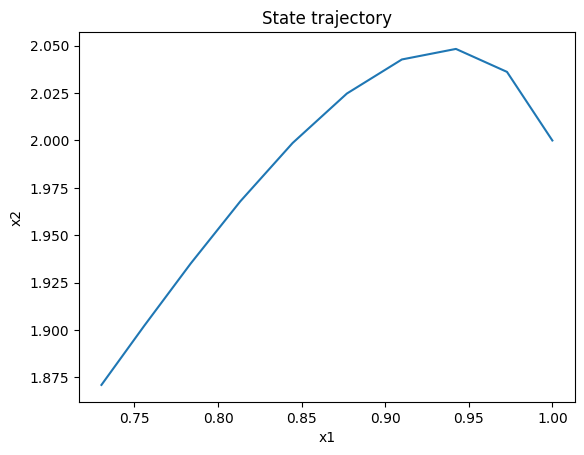

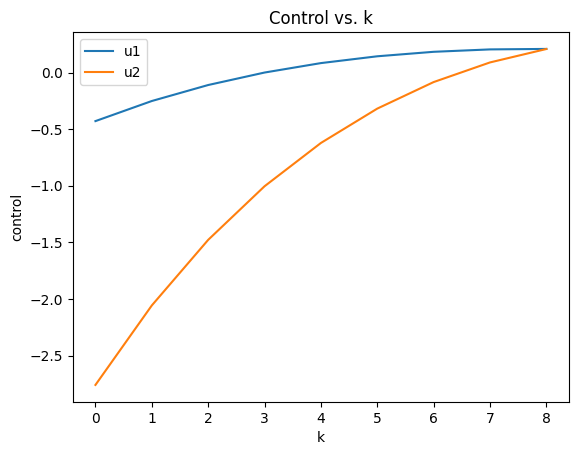

In [3]:
# LQR implementation goes in this cell

P_matrices = []
K_matrices = []

x_trajectory_lqr = np.zeros((N,4))
u_history_lqr = np.zeros((N-1, 2))


# vvvvvvv Fill code here. vvvvvvv

# as a result of your code, the P_matrices list defined above should contain the ten P matrices in increasing order of time,
# and the K_matrices list defined above should contain the nine K matrices in increasing order of time.
#
# x_trajectory_lqr should contain the complete state trajectory (with the k-th row of x_trajectory_lqr containing
# the state at time k), and likewise u_history_lqr should contain the complete control history (with the k-th row
# of u_history_lqr containing the control at time k).

P_matrices.append(Q_N)
for i in range(N-1):
    P_next = P_matrices[0]
    P = Q + A.T @ P_next @ A - A.T @ P_next @ B @ np.linalg.inv(R + B.T @ P_next @ B) @ B.T @ P_next @ A
    P_matrices = [P] + P_matrices

    K = -np.linalg.inv(R + B.T @ P_next @ B) @ B.T @ P_next @ A
    K_matrices = [K] + K_matrices

x_trajectory_lqr[0,:] = x_init

for i in range(N-1):
    K = K_matrices[i]
    u = K @ x_trajectory_lqr[i,:]

    u_history_lqr[i,:] = u
    x_trajectory_lqr[i+1, :] = A @ x_trajectory_lqr[i, :] + B @ u


# ^^^^^^^ Fill code here. ^^^^^^^

# Provided plotting code
plt.plot(x_trajectory_lqr[:,0], x_trajectory_lqr[:,1])
plt.title("State trajectory")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

plt.plot(range(N-1), u_history_lqr[:,0], label="u1")
plt.plot(range(N-1), u_history_lqr[:,1], label="u2")
plt.legend()
plt.title("Control vs. k")
plt.xlabel("k")
plt.ylabel("control")
plt.show()

In the following cell, directly find a state trajectory and control history that solves the same LQR optimization problem using cvx. The provided plotting code at the end of the cell will plot the resulting state trajectory and control history.

Hint: you may find the cvxpy function `quad_form` (documented [here](https://www.cvxpy.org/api_reference/cvxpy.atoms.other_atoms.html#quad-form)) useful. Since $Q$ and $R$ are both positive (semi)definite, the quadratic forms $x^TQx$ and $u^TRu$ are convex, but because of subtleties of [the way cvxpy works](https://www.cvxpy.org/tutorial/dcp/index.html), cvxpy does not immediately recognize those expressions as convex in general. `quad_form` provides additional information to cvxpy that allows it to determine the convexity of those expressions.

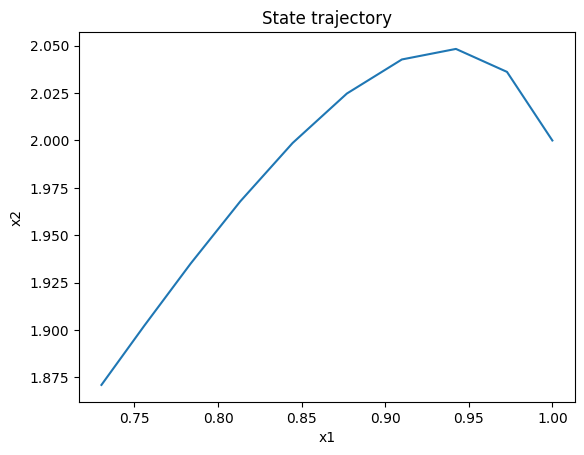

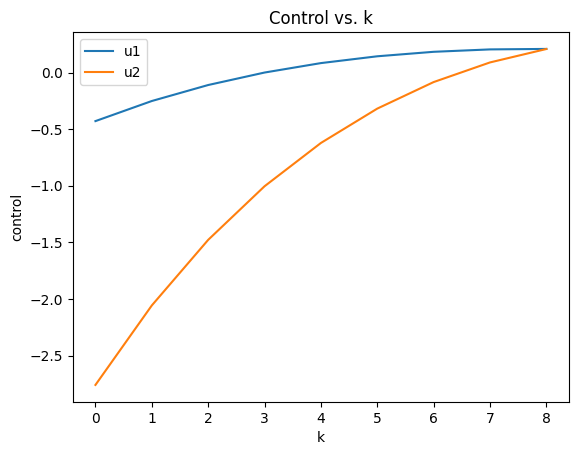

In [4]:
# CVX implementation goes in this cell

x_trajectory_cvx = np.zeros((N,4))
u_history_cvx = np.zeros((N-1, 2))

# vvvvvvv Fill code here. vvvvvvv

# As a result of your code, x_trajectory_cvx should contain the complete state trajectory (with the k-th row of x_trajectory_cvx containing
# the state at time k), and likewise u_history_cvx should contain the complete control history (with the k-th row of u_history_cvx
# containing the control at time k).

x_cvx = cp.Variable((N,4))
u_cvx = cp.Variable((N-1,2))

cost = cp.quad_form(x_cvx[-1,:], Q_N)
for i in range(N-1):
    cost += cp.quad_form(x_cvx[i,:], Q) + cp.quad_form(u_cvx[i,:], R)

objective = cp.Minimize(cost)
constraints = [x_cvx[0,:] == x_init]
for i in range(N-1):
    constraints += [x_cvx[i+1,:] == A @ x_cvx[i,:] + B @ u_cvx[i,:]]

problem = cp.Problem(objective, constraints)
problem.solve(solver='CLARABEL')

x_trajectory_cvx = x_cvx.value
u_history_cvx = u_cvx.value


# ^^^^^^^ Fill code here. ^^^^^^^

# Provided plotting code
plt.plot(x_trajectory_cvx[:,0], x_trajectory_cvx[:,1])
plt.title("State trajectory")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

plt.plot(range(N-1), u_history_cvx[:,0], label="u1")
plt.plot(range(N-1), u_history_cvx[:,1], label="u2")
plt.legend()
plt.title("Control vs. k")
plt.xlabel("k")
plt.ylabel("control")
plt.show()

Run the cell below to check that the solutions found by both methods match.

In [5]:
print("States match:", np.allclose(x_trajectory_cvx, x_trajectory_lqr))
print("Controls match:", np.allclose(u_history_cvx, u_history_lqr))

States match: True
Controls match: True


### (d) Open-loop vs. closed-loop

You should have gotten the same results from LQR and cvxpy in the previous part. LQR is a method of designing a _closed-loop controller_ that minimizes $J(\mathbf{x}, \mathbf{u})$. In contrast, the trajectory optimization with cvxpy is an _open-loop_ method, which designs an entire trajectory in advance and provides a numerical sequence of control inputs to achieve that trajectory; notably, the sequence of control inputs is given as a fixed, independent output of the optimizer, without reference to whatever the state may be at any point along the trajectory.

When and why might we prefer one technique over the other? Discuss.